## 1. Install Required Libraries

In [ ]:
# Uncomment if required:
# !pip install -q pandas numpy matplotlib seaborn nltk scikit-learn transformers torch datasets wordcloud

import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from transformers import pipeline
from datasets import load_dataset

from wordcloud import WordCloud

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Download NLP Resources

In [ ]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("NLTK resources are ready.")


NLTK resources are ready.


## 3. Collect Real Student Feedback Data

In [ ]:
DATASET_NAME = "yhua219/EduRABSA_SA"
LOCAL_CSV = "student_feedback_edurabsa.csv"

print("Downloading/loading the real EduRABSA student review dataset...")

dataset = load_dataset(DATASET_NAME)

# Combine available splits into one dataframe.
frames = []
for split_name in dataset.keys():
    split_df = dataset[split_name].to_pandas()
    split_df["split"] = split_name
    frames.append(split_df)

df = pd.concat(frames, ignore_index=True)

# Standardize column names.
df = df.rename(columns={
    "id": "feedback_id",
    "text": "feedback",
    "output": "sentiment_label"
})

required = {"feedback_id", "feedback", "sentiment_label"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Required columns missing from dataset: {missing}")

df["feedback"] = df["feedback"].astype(str).str.strip()
df["sentiment_label"] = df["sentiment_label"].astype(str).str.title()

df = df[df["feedback"].str.len() > 0]
df = df.drop_duplicates(subset=["feedback"]).reset_index(drop=True)

# Save a real local CSV for the project.
df.to_csv(LOCAL_CSV, index=False)

print(f"Real dataset loaded: {len(df):,} student reviews")
print(f"Local CSV created: {LOCAL_CSV}")
print("\nColumns:")
print(df.columns.tolist())

display(df.head())


Downloading/loading the real EduRABSA student review dataset...


README.md:   0%|          | 0.00/4.02k [00:00<?, ?B/s]

train/data-00000-of-00001.arrow: reconstructing file:   0%|          |  0.00B / 1.14MB            

train/data-00000-of-00001.arrow: downloading bytes:           |  0.00B            

test/data-00000-of-00001.arrow: reconstructing file:   0%|          |  0.00B /  727kB            

test/data-00000-of-00001.arrow: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Real dataset loaded: 6,491 student reviews
Local CSV created: student_feedback_edurabsa.csv

Columns:
['feedback_id', 'task_type', 'original_id', 'feedback', 'sentiment_label', 'split']


,feedback_id,task_type,original_id,feedback,sentiment_label,split
0,SC_101,sentiment analysis,2_11074_250,"exams are full MC, you can kinda guess the ans...",Neutral,train
1,SC_102,sentiment analysis,2_1423_1309,"Notes were unorganized and no help on piazza, ...",Negative,train
2,SC_103,sentiment analysis,2_2620_941,EWWWWW worst class ever,Negative,train
3,SC_104,sentiment analysis,2_5630_873,"Interesting material, but some parts are trick...",Neutral,train
4,SC_105,sentiment analysis,1_37_2340_3837,"Very organized, test to the lecture notes accu...",Neutral,train


## 4. Dataset Overview

In [ ]:
print("Dataset shape:", df.shape)

print("\nSentiment labels:")
display(df["sentiment_label"].value_counts().rename("count"))

print("\nMissing values:")
display(df.isna().sum())

df["word_count"] = df["feedback"].str.findall(r"\b\w+\b").str.len()

print("\nReview length statistics:")
display(df["word_count"].describe())


Dataset shape: (6491, 6)

Sentiment labels:


,count
sentiment_label,
Positive,3400
Negative,1598
Neutral,1491
,2



Missing values:


,0
feedback_id,0
task_type,0
original_id,0
feedback,0
sentiment_label,0
split,0



Review length statistics:


,word_count
count,6491.000000
mean,40.570636
std,33.448842
min,0.000000
25%,17.000000
50%,35.000000
75%,58.000000
max,446.000000


## 5. Sentiment Distribution in the Real Dataset

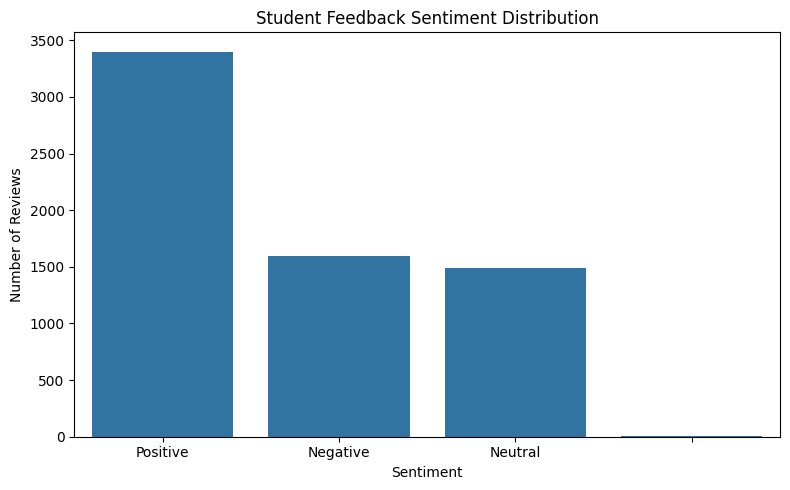

,percentage
sentiment_label,
Positive,52.38
Negative,24.62
Neutral,22.97
,0.03


In [ ]:
sentiment_counts = df["sentiment_label"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Student Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

sentiment_percent = (sentiment_counts / len(df) * 100).round(2)
display(sentiment_percent.rename("percentage"))


## 6. Review Length Visualization

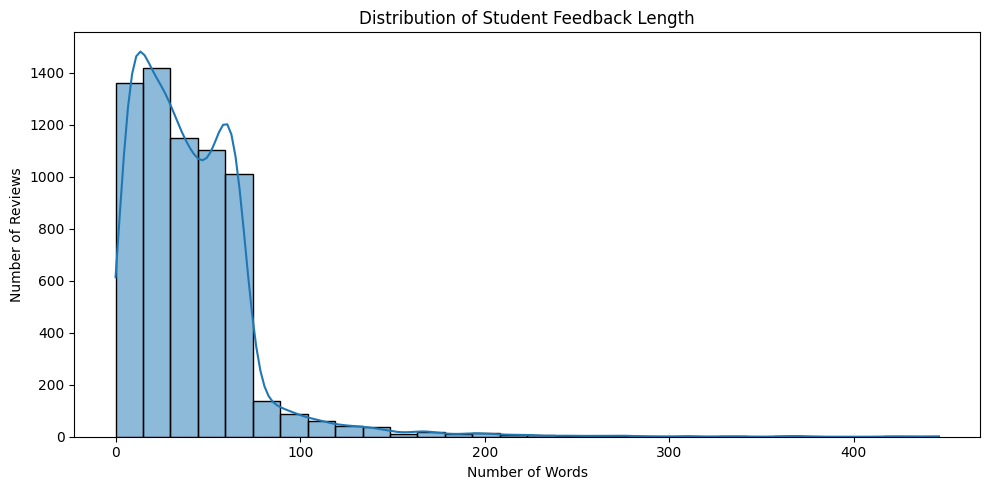

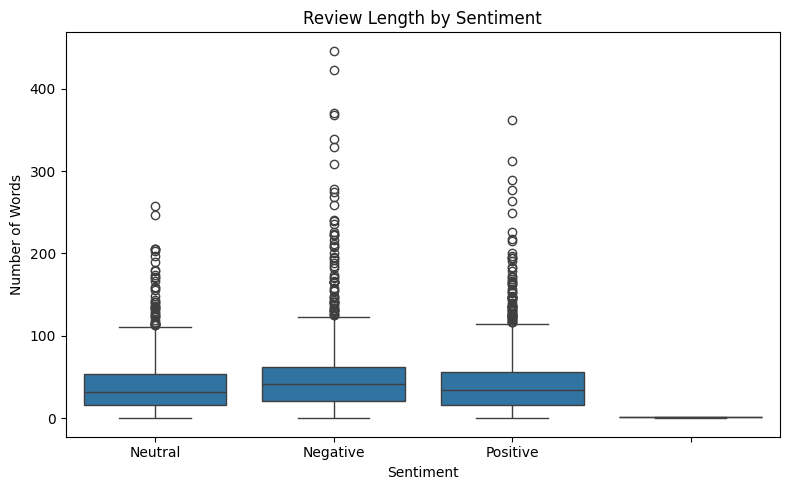

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Distribution of Student Feedback Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="sentiment_label", y="word_count")
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()


## 7. Text Preprocessing

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(tokens)

df["clean_feedback"] = df["feedback"].apply(preprocess_text)

display(df[["feedback", "clean_feedback"]].head(10))


,feedback,clean_feedback
0,"exams are full MC, you can kinda guess the ans...",exam full kinda guess answer using common sens...
1,"Notes were unorganized and no help on piazza, ...",note unorganized help piazza barely survived c...
2,EWWWWW worst class ever,worst class ever
3,"Interesting material, but some parts are trick...",interesting material part tricky fortunately m...
4,"Very organized, test to the lecture notes accu...",organized test lecture note accurately found c...
5,Fine university just nothing particularly stan...,fine university nothing particularly stand
6,"Read table, linearly interpolate, plug into ca...",read table linearly interpolate plug calculato...
7,"Good course, Interesting material. Prof can be...",good course interesting material prof harsh gr...
8,Easiest second year MATH/ CS course.,easiest second year math course
9,Don't do it! She's an awful instructor. My cla...,awful instructor class get syllabus week cours...


## 8. Transformer-Based Sentiment Analysis

In [ ]:
MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

try:
    sentiment_model = pipeline(
        "sentiment-analysis",
        model=MODEL_NAME,
        tokenizer=MODEL_NAME
    )
    print("Transformer sentiment model loaded successfully.")
except Exception as e:
    print("Could not load the transformer model.")
    print("Error:", e)
    sentiment_model = None


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Transformer sentiment model loaded successfully.


## 9. Predict Sentiment

In [ ]:
def predict_sentiment(texts, batch_size=16):
    if sentiment_model is None:
        raise RuntimeError(
            "The transformer model is unavailable. "
            "Check your internet connection/model installation and rerun the model-loading cell."
        )

    return sentiment_model(
        list(texts),
        batch_size=batch_size,
        truncation=True,
        max_length=256
    )

results = predict_sentiment(df["feedback"])

df["predicted_sentiment"] = [r["label"].title() for r in results]
df["prediction_confidence"] = [round(float(r["score"]), 4) for r in results]

display(
    df[
        ["feedback", "sentiment_label", "predicted_sentiment", "prediction_confidence"]
    ].head(15)
)


,feedback,sentiment_label,predicted_sentiment,prediction_confidence
0,"exams are full MC, you can kinda guess the ans...",Neutral,Negative,0.9991
1,"Notes were unorganized and no help on piazza, ...",Negative,Negative,0.9997
2,EWWWWW worst class ever,Negative,Negative,0.9998
3,"Interesting material, but some parts are trick...",Neutral,Positive,0.9595
4,"Very organized, test to the lecture notes accu...",Neutral,Negative,0.9978
5,Fine university just nothing particularly stan...,Neutral,Negative,0.9960
6,"Read table, linearly interpolate, plug into ca...",Neutral,Negative,0.9943
7,"Good course, Interesting material. Prof can be...",Neutral,Positive,0.9749
8,Easiest second year MATH/ CS course.,Positive,Positive,0.9968
9,Don't do it! She's an awful instructor. My cla...,Negative,Negative,0.9990


## 10. Evaluate Transformer Sentiment Against the Dataset Labels

Accuracy: 0.7104

Classification Report:
              precision    recall  f1-score   support

    Positive       0.77      0.93      0.84      3400
     Neutral       0.00      0.00      0.00      1491
    Negative       0.60      0.91      0.73      1598

   micro avg       0.71      0.71      0.71      6489
   macro avg       0.46      0.61      0.52      6489
weighted avg       0.55      0.71      0.62      6489



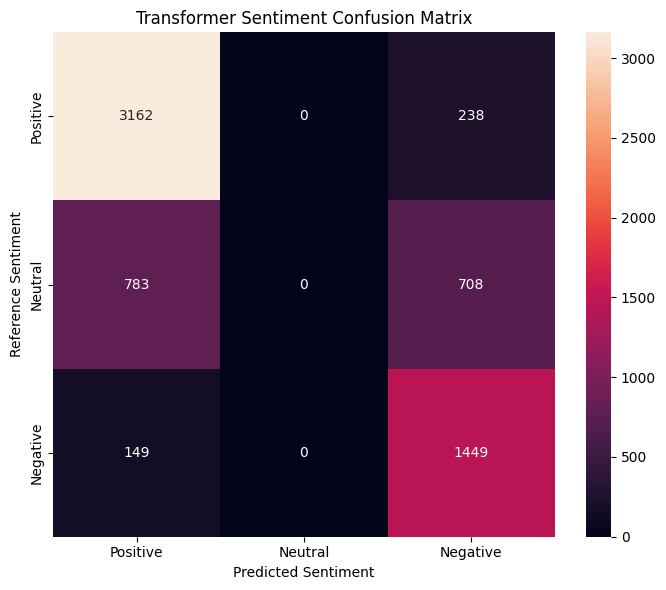

In [ ]:
y_true = df["sentiment_label"]
y_pred = df["predicted_sentiment"]

print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=["Positive", "Neutral", "Negative"],
        zero_division=0
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["Positive", "Neutral", "Negative"]
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"]
)
plt.title("Transformer Sentiment Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Reference Sentiment")
plt.tight_layout()
plt.show()


## 11. TF-IDF Keyword Extraction

,term,tfidf_score
4,course,0.145127
2,class,0.135376
5,easy,0.074363
32,really,0.064718
9,good,0.063077
11,great,0.062128
29,professor,0.058853
21,lot,0.057010
33,student,0.052928
35,teacher,0.052077


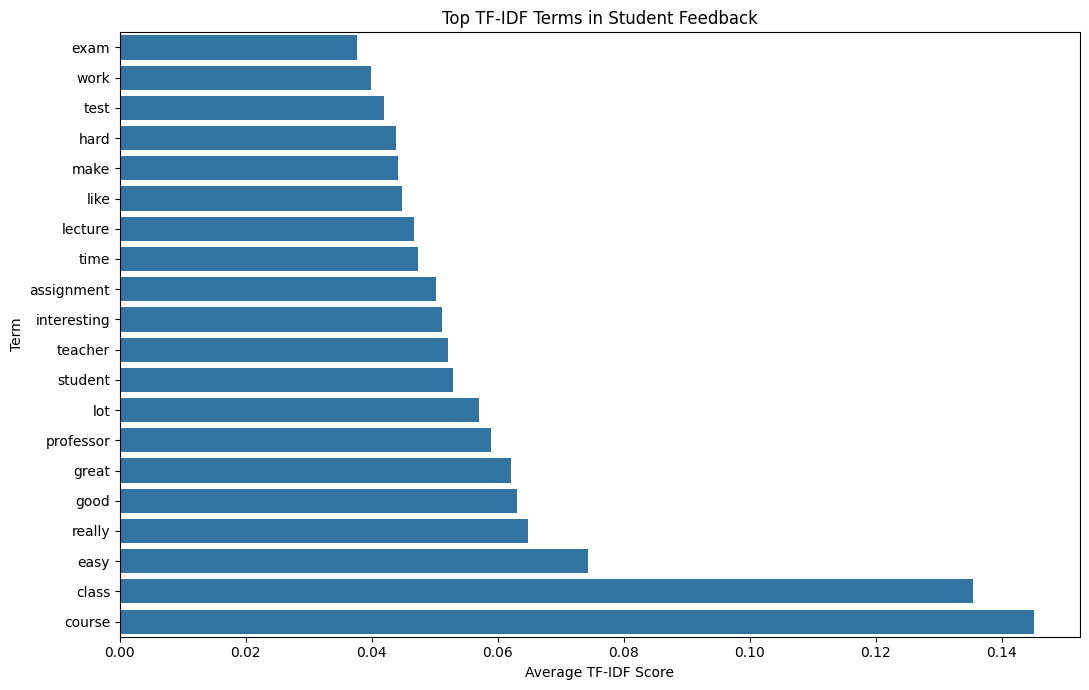

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=40,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3
)

tfidf_matrix = vectorizer.fit_transform(df["clean_feedback"])
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_terms = pd.DataFrame({
    "term": vectorizer.get_feature_names_out(),
    "tfidf_score": tfidf_scores
}).sort_values("tfidf_score", ascending=False)

display(tfidf_terms.head(25))

top_terms = tfidf_terms.head(20).sort_values("tfidf_score")

plt.figure(figsize=(11, 7))
sns.barplot(data=top_terms, x="tfidf_score", y="term")
plt.title("Top TF-IDF Terms in Student Feedback")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


## 12. Education-Specific Concern Extraction

In [ ]:
concern_keywords = {
    "Teaching Quality": [
        "teach", "teacher", "professor", "prof", "lecture", "lectures",
        "instructor", "explaining", "explanation", "teaching", "lecturer"
    ],
    "Course Content": [
        "course", "content", "topic", "topics", "syllabus", "material",
        "concept", "concepts", "curriculum"
    ],
    "Learning Activities": [
        "activity", "activities", "discussion", "group", "participation",
        "interactive", "interaction", "lab", "laboratory"
    ],
    "Assessment & Exams": [
        "exam", "exams", "test", "tests", "quiz", "quizzes", "midterm",
        "final", "grade", "grading", "mark", "marks", "assessment"
    ],
    "Assignments & Workload": [
        "assignment", "assignments", "homework", "workload", "work",
        "busywork", "deadline", "deadlines", "weekly", "hours"
    ],
    "Course Difficulty": [
        "hard", "difficult", "difficulty", "easy", "challenging",
        "tough", "complex", "stress", "stressful"
    ],
    "Learning Materials": [
        "notes", "textbook", "book", "reading", "readings", "slides",
        "powerpoint", "material", "materials", "resources"
    ],
    "Faculty Support": [
        "help", "helpful", "support", "office", "email", "respond",
        "response", "available", "guidance", "feedback"
    ],
    "Technology & Online Learning": [
        "online", "zoom", "blackboard", "canvas", "youtube", "website",
        "technology", "platform", "software", "stream"
    ],
    "Facilities & Campus": [
        "campus", "facility", "facilities", "library", "lab", "classroom",
        "building", "room", "equipment"
    ],
    "Student Experience": [
        "experience", "enjoy", "enjoyable", "boring", "fun", "interesting",
        "life", "student", "students", "satisfaction"
    ]
}

def detect_concerns(text):
    clean = preprocess_text(text)
    found = []

    for concern, keywords in concern_keywords.items():
        if any(
            re.search(r"\b" + re.escape(keyword) + r"\b", clean)
            for keyword in keywords
        ):
            found.append(concern)

    return found if found else ["General"]

df["concerns"] = df["feedback"].apply(detect_concerns)

display(df[["feedback", "concerns"]].head(15))


,feedback,concerns
0,"exams are full MC, you can kinda guess the ans...","[Assessment & Exams, Learning Materials]"
1,"Notes were unorganized and no help on piazza, ...","[Assessment & Exams, Faculty Support]"
2,EWWWWW worst class ever,[General]
3,"Interesting material, but some parts are trick...","[Course Content, Assessment & Exams, Assignmen..."
4,"Very organized, test to the lecture notes accu...","[Teaching Quality, Assessment & Exams]"
5,Fine university just nothing particularly stan...,[General]
6,"Read table, linearly interpolate, plug into ca...",[General]
7,"Good course, Interesting material. Prof can be...","[Teaching Quality, Course Content, Learning Ac..."
8,Easiest second year MATH/ CS course.,[Course Content]
9,Don't do it! She's an awful instructor. My cla...,"[Teaching Quality, Course Content, Assessment ..."


## 13. Common Student Concerns

,concern,mentions
0,Teaching Quality,2792
1,Course Content,2743
2,Student Experience,2297
3,Course Difficulty,2296
4,Assessment & Exams,2228
5,Assignments & Workload,1521
6,Learning Materials,1241
7,Faculty Support,1197
8,Learning Activities,643
9,Facilities & Campus,580


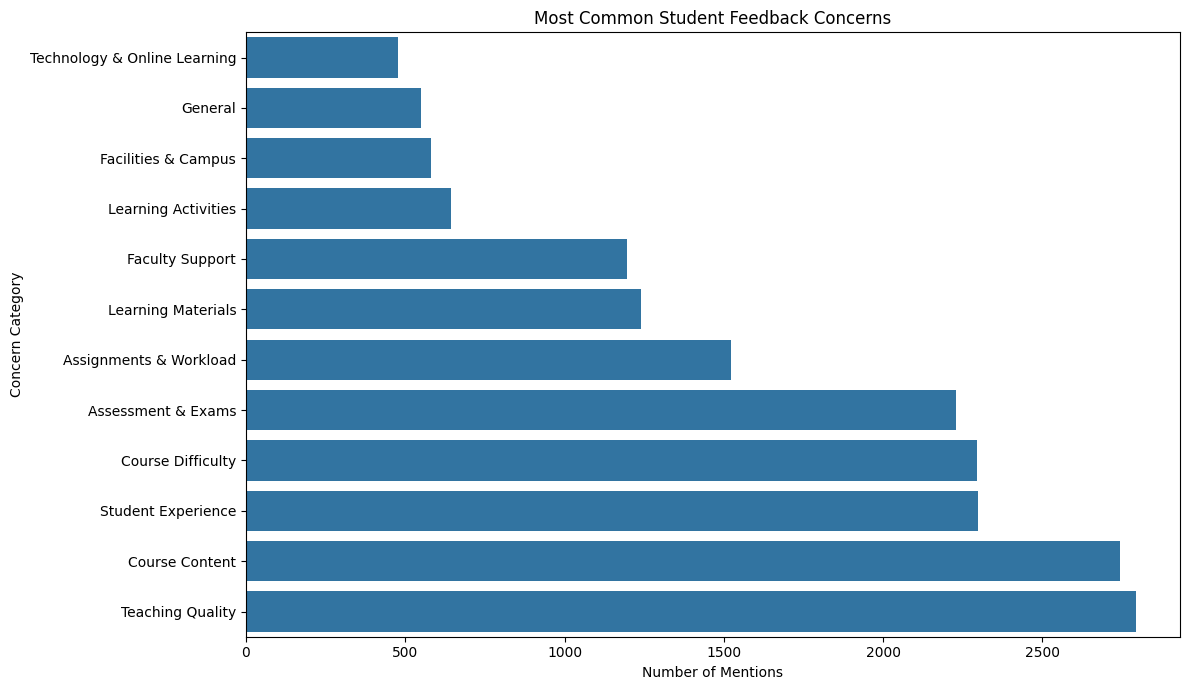

In [ ]:
concern_rows = []

for _, row in df.iterrows():
    for concern in row["concerns"]:
        concern_rows.append({
            "concern": concern,
            "reference_sentiment": row["sentiment_label"],
            "predicted_sentiment": row["predicted_sentiment"],
            "feedback": row["feedback"]
        })

concern_df = pd.DataFrame(concern_rows)

concern_counts = (
    concern_df["concern"]
    .value_counts()
    .reset_index()
)
concern_counts.columns = ["concern", "mentions"]

display(concern_counts)

plt.figure(figsize=(12, 7))
plot_data = concern_counts.sort_values("mentions")

sns.barplot(data=plot_data, x="mentions", y="concern")
plt.title("Most Common Student Feedback Concerns")
plt.xlabel("Number of Mentions")
plt.ylabel("Concern Category")
plt.tight_layout()
plt.show()


## 14. Concern-wise Sentiment Analysis

reference_sentiment,Positive,Neutral,Negative
concern,,,
Assessment & Exams,993,559,676
Assignments & Workload,775,376,370
Course Content,1233,810,700
Course Difficulty,1086,642,568
Facilities & Campus,311,161,108
Faculty Support,818,165,214
General,287,130,129
Learning Activities,298,185,160
Learning Materials,614,290,337


<Figure size 1300x800 with 0 Axes>

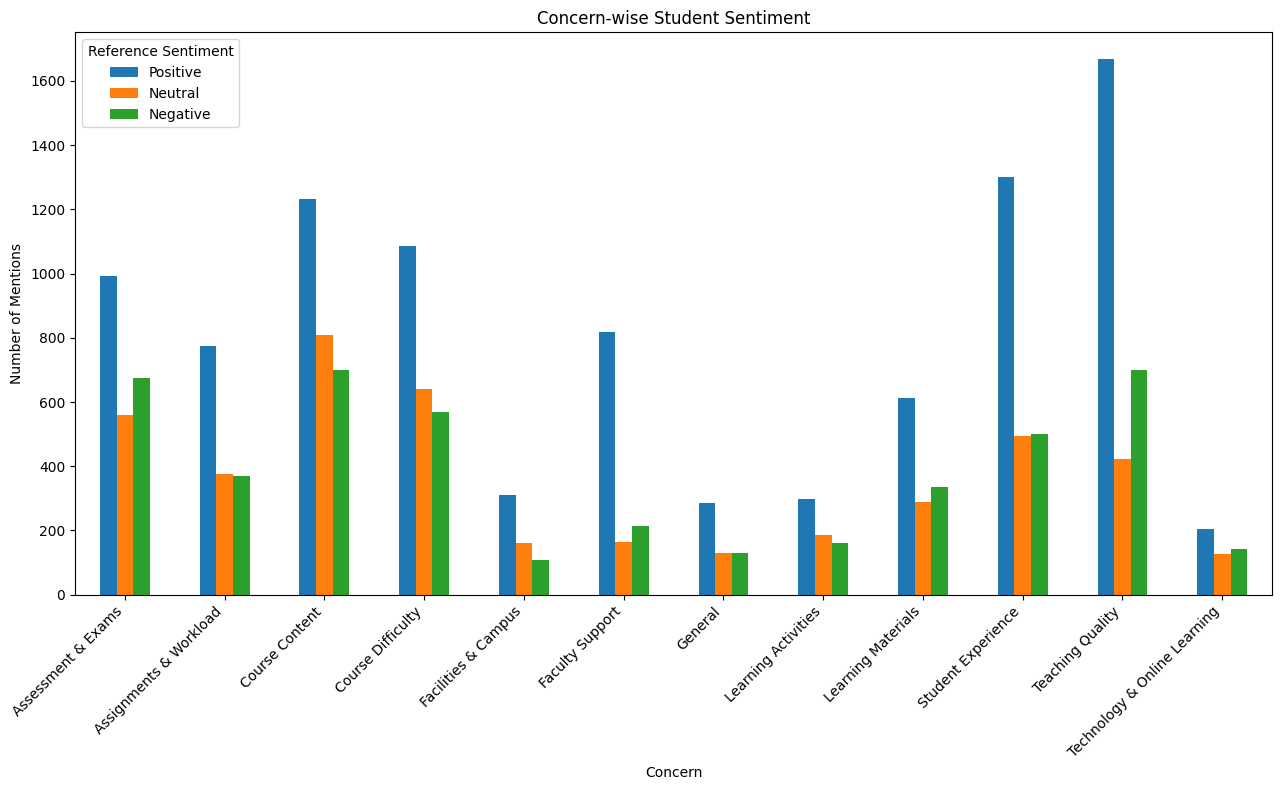

In [ ]:
concern_sentiment = pd.crosstab(
    concern_df["concern"],
    concern_df["reference_sentiment"]
)

for col in ["Positive", "Neutral", "Negative"]:
    if col not in concern_sentiment.columns:
        concern_sentiment[col] = 0

concern_sentiment = concern_sentiment[["Positive", "Neutral", "Negative"]]

display(concern_sentiment)

plt.figure(figsize=(13, 8))
concern_sentiment.plot(
    kind="bar",
    figsize=(13, 8)
)
plt.title("Concern-wise Student Sentiment")
plt.xlabel("Concern")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Reference Sentiment")
plt.tight_layout()
plt.show()


## 15. Identify High-Priority Student Concerns

In [ ]:
concern_summary = concern_df.groupby("concern").agg(
    total_mentions=("concern", "size"),
    negative_mentions=("reference_sentiment", lambda x: (x == "Negative").sum()),
    neutral_mentions=("reference_sentiment", lambda x: (x == "Neutral").sum()),
    positive_mentions=("reference_sentiment", lambda x: (x == "Positive").sum())
).reset_index()

concern_summary["negative_rate"] = (
    concern_summary["negative_mentions"] /
    concern_summary["total_mentions"] * 100
).round(2)

concern_summary["priority_score"] = (
    concern_summary["negative_mentions"] * 0.7 +
    concern_summary["negative_rate"] * 0.3
).round(2)

priority_concerns = concern_summary[
    concern_summary["negative_mentions"] > 0
].sort_values(
    ["priority_score", "negative_mentions"],
    ascending=False
)

display(priority_concerns)


,concern,total_mentions,negative_mentions,neutral_mentions,positive_mentions,negative_rate,priority_score
2,Course Content,2743,700,810,1233,25.52,497.66
10,Teaching Quality,2792,700,424,1668,25.07,497.52
0,Assessment & Exams,2228,676,559,993,30.34,482.30
3,Course Difficulty,2296,568,642,1086,24.74,405.02
9,Student Experience,2297,501,494,1302,21.81,357.24
1,Assignments & Workload,1521,370,376,775,24.33,266.30
8,Learning Materials,1241,337,290,614,27.16,244.05
5,Faculty Support,1197,214,165,818,17.88,155.16
7,Learning Activities,643,160,185,298,24.88,119.46
11,Technology & Online Learning,477,143,128,206,29.98,109.09


## 16. High-Priority Concern Visualization

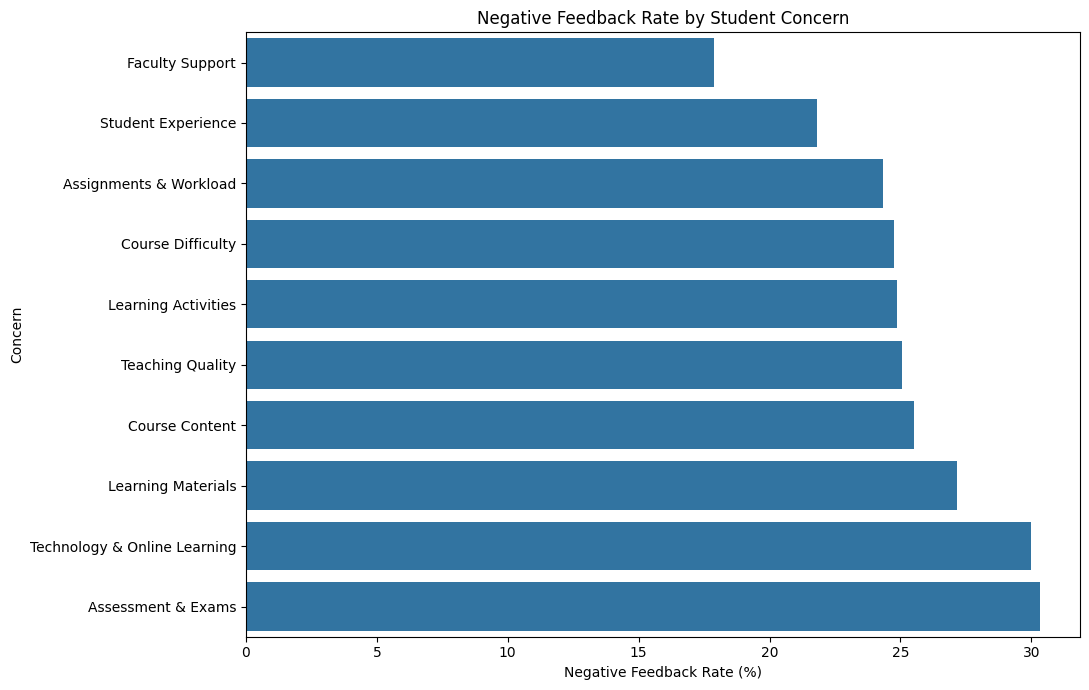

In [ ]:
plot_priority = priority_concerns.head(10).sort_values("negative_rate")

plt.figure(figsize=(11, 7))
sns.barplot(
    data=plot_priority,
    x="negative_rate",
    y="concern"
)
plt.title("Negative Feedback Rate by Student Concern")
plt.xlabel("Negative Feedback Rate (%)")
plt.ylabel("Concern")
plt.tight_layout()
plt.show()


## 17. Negative Feedback Word Cloud

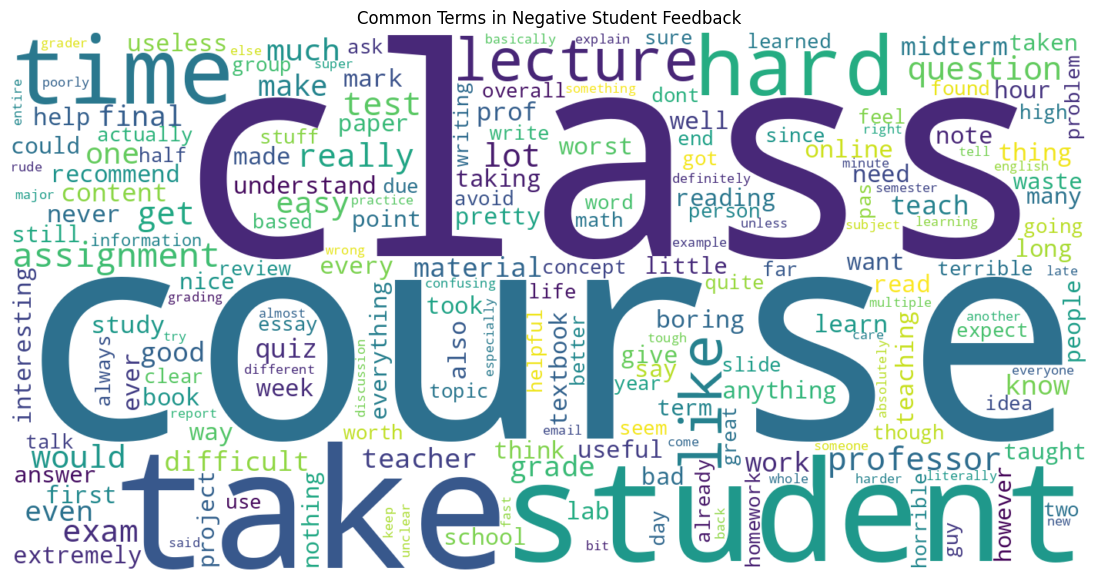

In [ ]:
negative_text = " ".join(
    df.loc[df["sentiment_label"] == "Negative", "clean_feedback"]
)

if negative_text.strip():
    wordcloud = WordCloud(
        width=1400,
        height=700,
        background_color="white",
        stopwords=stop_words,
        collocations=False
    ).generate(negative_text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Common Terms in Negative Student Feedback")
    plt.show()
else:
    print("No negative reviews were found.")


## 18. Representative Negative Feedback

In [ ]:
for concern in priority_concerns.head(7)["concern"]:
    examples = concern_df[
        (concern_df["concern"] == concern) &
        (concern_df["reference_sentiment"] == "Negative")
    ]["feedback"].drop_duplicates().head(3).tolist()

    print("\n" + "=" * 80)
    print(concern.upper())
    print("=" * 80)

    if examples:
        for i, example in enumerate(examples, 1):
            print(f"{i}. {example}")
    else:
        print("No negative examples available.")



COURSE CONTENT
1. Don't do it! She's an awful instructor. My class didn't get our syllabus until 3 weeks into the course& even once we did, she was constantly moving around deadlines. I only JUST got back papers that I turned in almost 2 months ago& I still don't have a letter grade for the course. The class wouldn't be so stressful& difficult if she was organized.
2. they don't teach you much about the assignments in the course, and that makes it hard
3. You may be able to expect your grade in 301 to be 10 % lower than your other JAPAN courses. Used to take JAPAN courses as bird courses, but this one really proved me wrong.

TEACHING QUALITY
1. Don't do it! She's an awful instructor. My class didn't get our syllabus until 3 weeks into the course& even once we did, she was constantly moving around deadlines. I only JUST got back papers that I turned in almost 2 months ago& I still don't have a letter grade for the course. The class wouldn't be so stressful& difficult if she was organi

## 19. Automated Improvement Suggestions

In [ ]:
suggestion_map = {
    "Teaching Quality":
        "Increase clarity of explanations, use more examples, and add interactive teaching techniques.",
    "Course Content":
        "Review the syllabus for unnecessary or unclear content and align topics with learning outcomes.",
    "Learning Activities":
        "Increase meaningful discussions, practical activities, labs, and student participation.",
    "Assessment & Exams":
        "Review assessment difficulty and grading consistency; provide clearer exam expectations and rubrics.",
    "Assignments & Workload":
        "Balance assignment volume, avoid overlapping deadlines, and provide realistic completion times.",
    "Course Difficulty":
        "Provide prerequisite guidance, additional practice material, and structured support for difficult topics.",
    "Learning Materials":
        "Improve organization and availability of lecture notes, readings, slides, and study resources.",
    "Faculty Support":
        "Increase availability for questions and improve response time for student doubts and feedback.",
    "Technology & Online Learning":
        "Improve reliability of online platforms and provide consistent access to recordings and digital resources.",
    "Facilities & Campus":
        "Review classroom, laboratory, library, and equipment availability where negative feedback is concentrated.",
    "Student Experience":
        "Increase engagement, practical relevance, and opportunities for students to participate actively."
}

print("IMPROVEMENT SUGGESTIONS")
print("=" * 80)

for _, row in priority_concerns.head(8).iterrows():
    concern = row["concern"]
    print(
        f"\n{concern} "
        f"(negative rate: {row['negative_rate']:.1f}%, "
        f"negative mentions: {int(row['negative_mentions'])})"
    )
    print("→", suggestion_map.get(
        concern,
        "Review representative negative comments and identify the underlying issue."
    ))


IMPROVEMENT SUGGESTIONS

Course Content (negative rate: 25.5%, negative mentions: 700)
→ Review the syllabus for unnecessary or unclear content and align topics with learning outcomes.

Teaching Quality (negative rate: 25.1%, negative mentions: 700)
→ Increase clarity of explanations, use more examples, and add interactive teaching techniques.

Assessment & Exams (negative rate: 30.3%, negative mentions: 676)
→ Review assessment difficulty and grading consistency; provide clearer exam expectations and rubrics.

Course Difficulty (negative rate: 24.7%, negative mentions: 568)
→ Provide prerequisite guidance, additional practice material, and structured support for difficult topics.

Student Experience (negative rate: 21.8%, negative mentions: 501)
→ Increase engagement, practical relevance, and opportunities for students to participate actively.

Assignments & Workload (negative rate: 24.3%, negative mentions: 370)
→ Balance assignment volume, avoid overlapping deadlines, and provide re

## 20. Executive Summary

In [ ]:
total_feedback = len(df)
positive_pct = df["sentiment_label"].eq("Positive").mean() * 100
neutral_pct = df["sentiment_label"].eq("Neutral").mean() * 100
negative_pct = df["sentiment_label"].eq("Negative").mean() * 100

print("=" * 80)
print("STUDENT FEEDBACK ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 80)
print(f"Total student reviews analyzed : {total_feedback:,}")
print(f"Positive feedback              : {positive_pct:.2f}%")
print(f"Neutral feedback               : {neutral_pct:.2f}%")
print(f"Negative feedback              : {negative_pct:.2f}%")

print("\nTop priority concerns:")
for i, row in enumerate(priority_concerns.head(5).itertuples(), 1):
    print(
        f"{i}. {row.concern} — "
        f"{row.negative_mentions} negative mentions "
        f"({row.negative_rate:.1f}% negative)"
    )

print("\nRecommended institutional actions:")
for row in priority_concerns.head(5).itertuples():
    print(f"• {row.concern}: {suggestion_map.get(row.concern, 'Review negative feedback for root causes.')}")

print("=" * 80)


STUDENT FEEDBACK ANALYSIS — EXECUTIVE SUMMARY
Total student reviews analyzed : 6,491
Positive feedback              : 52.38%
Neutral feedback               : 22.97%
Negative feedback              : 24.62%

Top priority concerns:
1. Course Content — 700 negative mentions (25.5% negative)
2. Teaching Quality — 700 negative mentions (25.1% negative)
3. Assessment & Exams — 676 negative mentions (30.3% negative)
4. Course Difficulty — 568 negative mentions (24.7% negative)
5. Student Experience — 501 negative mentions (21.8% negative)

Recommended institutional actions:
• Course Content: Review the syllabus for unnecessary or unclear content and align topics with learning outcomes.
• Teaching Quality: Increase clarity of explanations, use more examples, and add interactive teaching techniques.
• Assessment & Exams: Review assessment difficulty and grading consistency; provide clearer exam expectations and rubrics.
• Course Difficulty: Provide prerequisite guidance, additional practice mate

In [ ]:
final_columns = [
    "feedback_id",
    "original_id",
    "feedback",
    "clean_feedback",
    "sentiment_label",
    "predicted_sentiment",
    "prediction_confidence",
    "concerns"
]

available_columns = [c for c in final_columns if c in df.columns]

final_df = df[available_columns].copy()

# Convert list-valued concerns into readable text for CSV.
final_df["concerns"] = final_df["concerns"].apply(
    lambda x: "; ".join(x) if isinstance(x, list) else str(x)
)

final_df.to_csv(
    "student_feedback_analysis_results.csv",
    index=False
)

display(final_df.head(20))

print("Saved: student_feedback_analysis_results.csv")


,feedback_id,original_id,feedback,clean_feedback,sentiment_label,predicted_sentiment,prediction_confidence,concerns
0,SC_101,2_11074_250,"exams are full MC, you can kinda guess the ans...",exam full kinda guess answer using common sens...,Neutral,Negative,0.9991,Assessment & Exams; Learning Materials
1,SC_102,2_1423_1309,"Notes were unorganized and no help on piazza, ...",note unorganized help piazza barely survived c...,Negative,Negative,0.9997,Assessment & Exams; Faculty Support
2,SC_103,2_2620_941,EWWWWW worst class ever,worst class ever,Negative,Negative,0.9998,General
3,SC_104,2_5630_873,"Interesting material, but some parts are trick...",interesting material part tricky fortunately m...,Neutral,Positive,0.9595,Course Content; Assessment & Exams; Assignment...
4,SC_105,1_37_2340_3837,"Very organized, test to the lecture notes accu...",organized test lecture note accurately found c...,Neutral,Negative,0.9978,Teaching Quality; Assessment & Exams
5,SC_106,3_124_516_228,Fine university just nothing particularly stan...,fine university nothing particularly stand,Neutral,Negative,0.9960,General
6,SC_107,2_9472_1669,"Read table, linearly interpolate, plug into ca...",read table linearly interpolate plug calculato...,Neutral,Negative,0.9943,General
7,SC_108,2_5556_748,"Good course, Interesting material. Prof can be...",good course interesting material prof harsh gr...,Neutral,Positive,0.9749,Teaching Quality; Course Content; Learning Act...
8,SC_109,2_1495_1309,Easiest second year MATH/ CS course.,easiest second year math course,Positive,Positive,0.9968,Course Content
9,SC_110,1_89_2465_4547,Don't do it! She's an awful instructor. My cla...,awful instructor class get syllabus week cours...,Negative,Negative,0.9990,Teaching Quality; Course Content; Assessment &...


Saved: student_feedback_analysis_results.csv
